# Bank Marketing Dataset: SQL + Python Analysis
This notebook explores the Bank Marketing dataset using DBeaver (PostgreSQL) and Python visualizations. The goal is to identify patterns that lead to term deposit subscription.

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("default")

In [55]:
df = pd.read_csv('bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,Target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Age Distribution
This histogram shows the age distribution of customers.

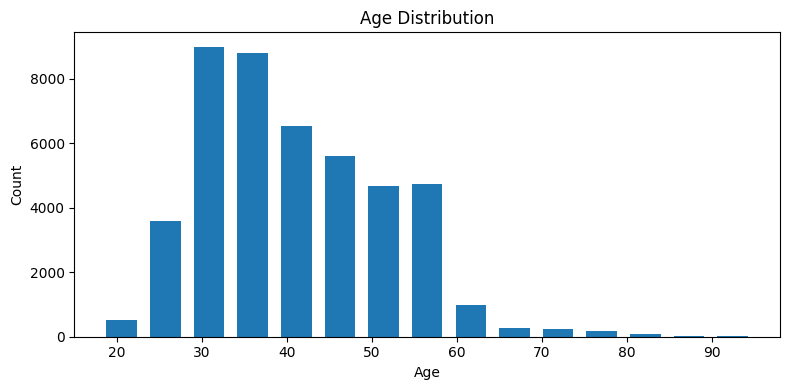

In [56]:
plt.figure(figsize=(8,4))
plt.hist(df['age'].dropna(), bins=15, rwidth=0.7)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.tight_layout()
plt.show()

## Conversion Rate by Job
We calculate conversion rate for each job category and visualize it.
This reveals which professions are most responsive to marketing calls.

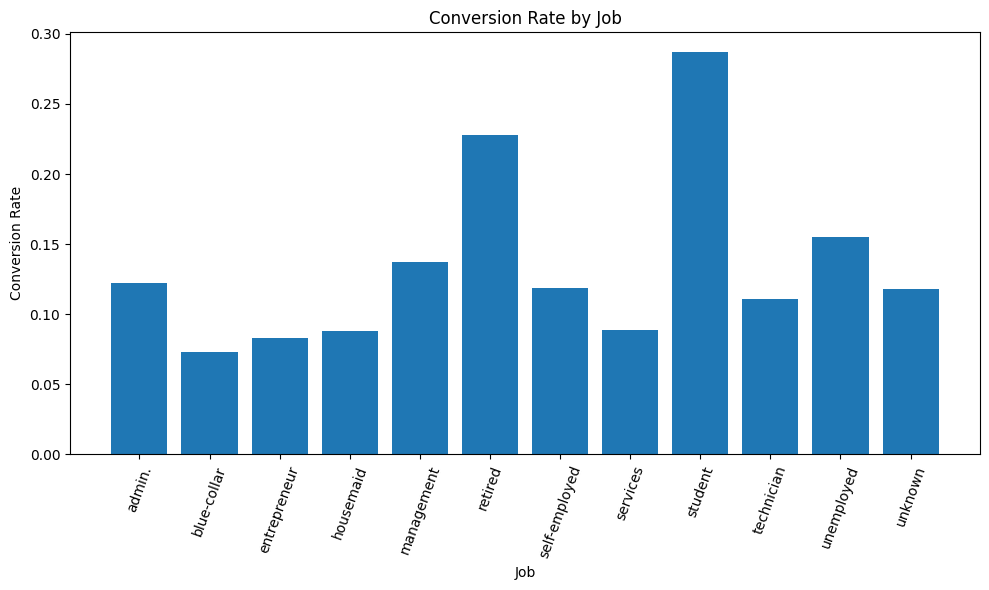

In [57]:
conv_job = df.groupby("job")["Target"].apply(lambda x: (x == "yes").mean()).reset_index()

plt.figure(figsize=(10,6))
plt.bar(conv_job["job"], conv_job["Target"])
plt.xticks(rotation=70)
plt.xlabel("Job")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Job")
plt.tight_layout()
plt.show()

## Subscription Distribution (Yes vs No)
A bar chart that compares how many people subscribed vs. did not subscribe.  
This helps reveal class imbalance in the dataset.

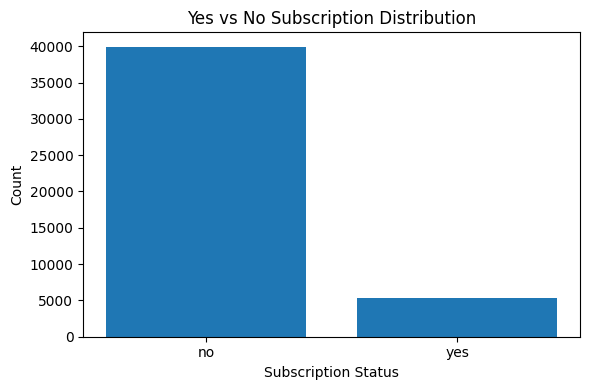

In [58]:
counts = df["Target"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.xlabel("Subscription Status")
plt.ylabel("Count")
plt.title("Yes vs No Subscription Distribution")
plt.tight_layout()
plt.show()

## Conversion Rate by Age Group
We bucket customers into age groups and analyze conversion rates within each group.
This reveals which age segments are most likely to subscribe.

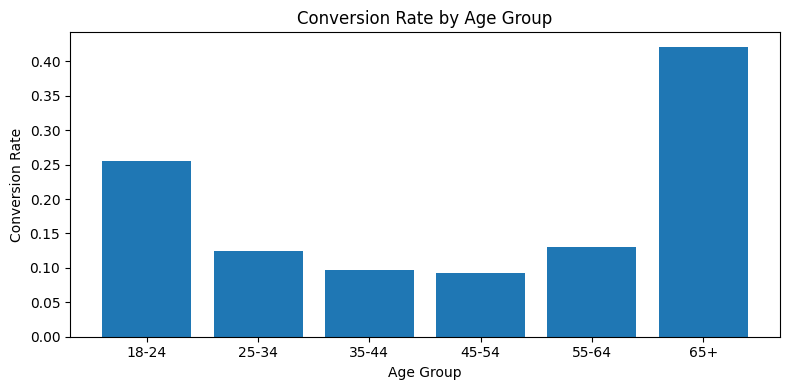

In [59]:
def age_bucket(age):
    if age < 25: return "18-24"
    elif age < 35: return "25-34"
    elif age < 45: return "35-44"
    elif age < 55: return "45-54"
    elif age < 65: return "55-64"
    else: return "65+"

df["age_group"] = df["age"].apply(age_bucket)
conv_age = df.groupby("age_group")["Target"].apply(lambda x: (x=="yes").mean()).reset_index()

plt.figure(figsize=(8,4))
plt.bar(conv_age["age_group"], conv_age["Target"])
plt.xlabel("Age Group")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Age Group")
plt.tight_layout()
plt.show()